# 02 — Modeling Pipeline
### Binary Network Intrusion Detection: Normal vs. Attack

Three classifiers are trained and compared on the preprocessed UNSW-NB15 dataset.

| Model | Role |
|---|---|
| Logistic Regression | Linear baseline |
| Random Forest | Ensemble benchmark |
| XGBoost | Primary model |

**Sampling:** A stratified 500k-row sample is used by default to keep training time
reasonable on local hardware. Set `SAMPLE_SIZE = None` to train on the full 2.54M rows.

**Outputs**
- `models/xgb_model.joblib` — saved XGBoost pipeline
- `models/feature_meta.json` — feature name metadata for notebook 03
- `data/processed/X_test.parquet`, `data/processed/y_test.parquet`

In [1]:
import os
print("Working directory:", os.getcwd())
print("Parquet exists:", os.path.exists("data/processed/traffic_cleaned.parquet"))
print("data/ contents:", os.listdir("data/processed") if os.path.exists("data/processed") else "folder missing")


Working directory: /home/username/ML/congenial-lamp
Parquet exists: True
data/ contents: ['fig_protocol_state.png', 'fig_class_balance.png', 'fig_attack_categories.png', 'traffic_cleaned.parquet', 'fig_correlation_heatmap.png', 'y_test.parquet', 'fig_feature_distributions.png', 'X_test.parquet']


In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 100})

os.makedirs("models", exist_ok=True)

/home/username/.local/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


## 1. Load Data

In [3]:
df = pd.read_parquet("data/processed/traffic_cleaned.parquet")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
counts = df["label"].value_counts().sort_index()
print(f"\nNormal  {counts[0]:>9,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"Attack  {counts[1]:>9,}  ({counts[1]/len(df)*100:.1f}%)")

Loaded: 2,540,047 rows × 45 columns

Normal  2,218,764  (87.4%)
Attack    321,283  (12.6%)


## 2. Feature Setup

- `attack_cat` is dropped — it directly encodes the label (data leakage).
- Categorical features are one-hot encoded; numerical features are standardized.
- `class_weight="balanced"` / `scale_pos_weight` compensate for the ~87/13 class split.

In [4]:
TARGET = "label"
DROP_FEATURES = ["attack_cat"]
CAT_FEATURES = ["proto", "state", "service"]
NUM_FEATURES = [
    c for c in df.columns
    if c not in CAT_FEATURES + DROP_FEATURES + [TARGET]
]

SAMPLE_SIZE = 500_000  # set to None to use full dataset

print(f"Categorical ({len(CAT_FEATURES)}): {CAT_FEATURES}")
print(f"Numerical   ({len(NUM_FEATURES)}): {NUM_FEATURES[:5]} ... ")

Categorical (3): ['proto', 'state', 'service']
Numerical   (40): ['sport', 'dsport', 'dur', 'sbytes', 'dbytes'] ... 


In [5]:
X = df.drop(columns=DROP_FEATURES + [TARGET])
y = df[TARGET]

if SAMPLE_SIZE:
    X, _, y, _ = train_test_split(
        X, y, train_size=SAMPLE_SIZE, stratify=y, random_state=42
    )
    print(f"Stratified sample: {X.shape[0]:,} rows")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Attack rate — Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}")

X_test.to_parquet("data/processed/X_test.parquet", index=False)
y_test.to_frame().to_parquet("data/processed/y_test.parquet", index=False)

Stratified sample: 500,000 rows
Train: 400,000  |  Test: 100,000
Attack rate — Train: 0.126  |  Test: 0.126


## 3. Preprocessing Pipeline

In [6]:
from sklearn.impute import SimpleImputer

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, NUM_FEATURES),
        ("cat", cat_pipe, CAT_FEATURES),
    ],
    remainder="drop",
)

# Save feature metadata for notebook 03
meta = {
    "NUM_FEATURES": NUM_FEATURES,
    "CAT_FEATURES": CAT_FEATURES,
    "TARGET": TARGET,
    "DROP_FEATURES": DROP_FEATURES,
}
with open("models/feature_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Preprocessing pipeline defined")
print(f"  Numerical  (impute → scale) : {len(NUM_FEATURES)} features")
print(f"  Categorical (impute → encode): {len(CAT_FEATURES)} features")
print("Saved → models/feature_meta.json")

Preprocessing pipeline defined
  Numerical  (impute → scale) : 40 features
  Categorical (impute → encode): 3 features
Saved → models/feature_meta.json


## 4. Model Training

In [7]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=42
        )),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=200, class_weight="balanced",
            n_jobs=-1, random_state=42,
        )),
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("clf", XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=pos_weight,
            eval_metric="logloss", random_state=42, n_jobs=-1,
        )),
    ]),
}

results = {}
for name, model in models.items():
    print(f"Training {name}...", end=" ", flush=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }
    print(f"done  |  F1={results[name]['f1']:.4f}  AUC={results[name]['roc_auc']:.4f}")

Training Logistic Regression... done  |  F1=0.9518  AUC=0.9993
Training Random Forest... done  |  F1=0.9766  AUC=0.9998
Training XGBoost... done  |  F1=0.9640  AUC=0.9997


## 5. Evaluation

In [8]:
for name, res in results.items():
    print(f"\n{'='*52}")
    print(f"  {name}")
    print("=" * 52)
    print(classification_report(y_test, res["y_pred"], target_names=["Normal", "Attack"]))


  Logistic Regression
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     87351
      Attack       0.91      1.00      0.95     12649

    accuracy                           0.99    100000
   macro avg       0.95      0.99      0.97    100000
weighted avg       0.99      0.99      0.99    100000


  Random Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     87351
      Attack       0.98      0.98      0.98     12649

    accuracy                           0.99    100000
   macro avg       0.99      0.99      0.99    100000
weighted avg       0.99      0.99      0.99    100000


  XGBoost
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     87351
      Attack       0.94      0.99      0.96     12649

    accuracy                           0.99    100000
   macro avg       0.97      0.99      0.98    100000
weighted avg       0.99

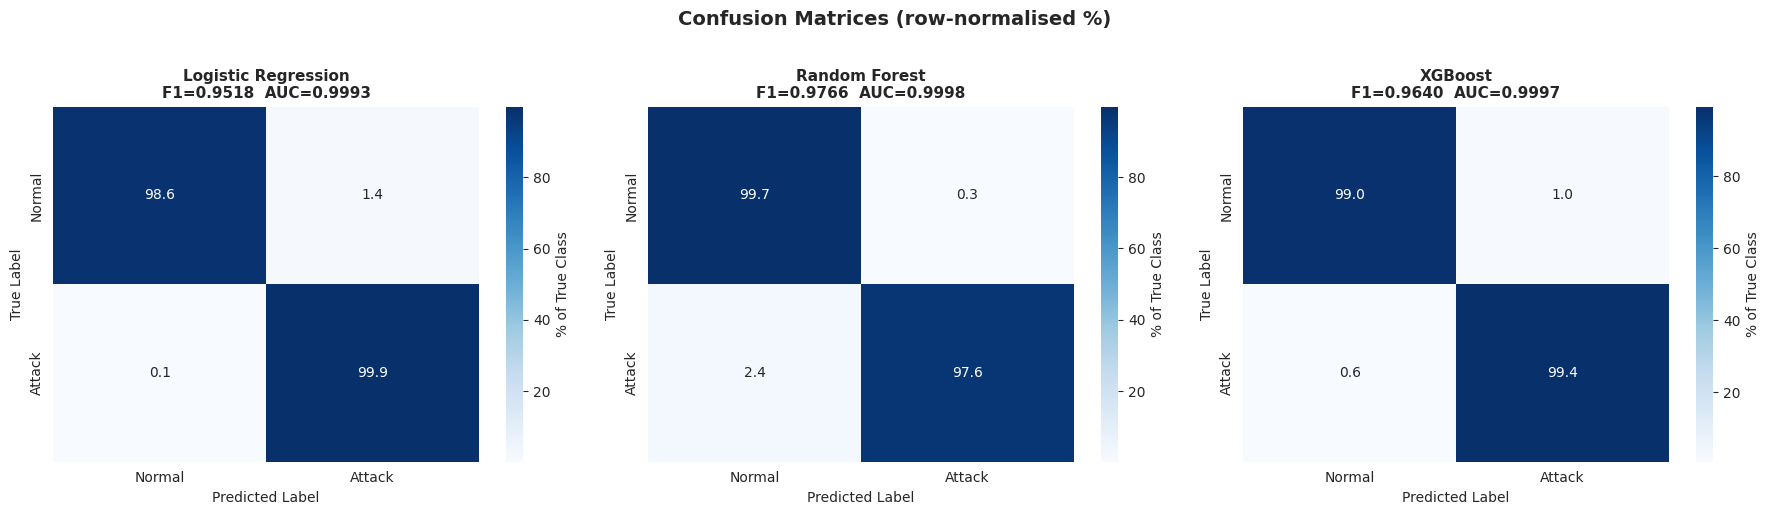

In [9]:
# Confusion matrices (row-normalised %)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(
        cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=ax,
        xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"],
        cbar_kws={"label": "% of True Class"},
    )
    ax.set_title(
        f"{name}\nF1={res['f1']:.4f}  AUC={res['roc_auc']:.4f}",
        fontsize=11, fontweight="bold",
    )
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.suptitle("Confusion Matrices (row-normalised %)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/processed/fig_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

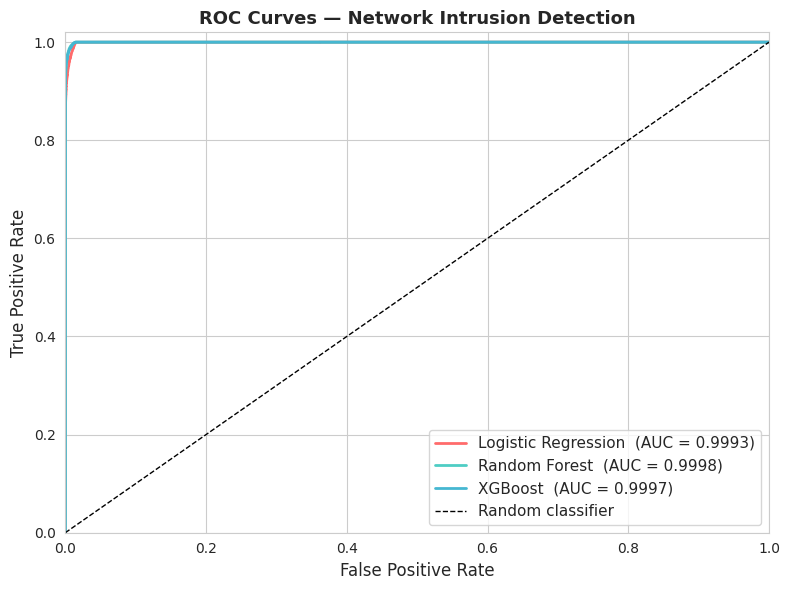

In [10]:
# ROC curves
plt.figure(figsize=(8, 6))
colors = ["#FF6B6B", "#4ECDC4", "#45B7D1"]
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f"{name}  (AUC = {res['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — Network Intrusion Detection", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.savefig("data/processed/fig_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

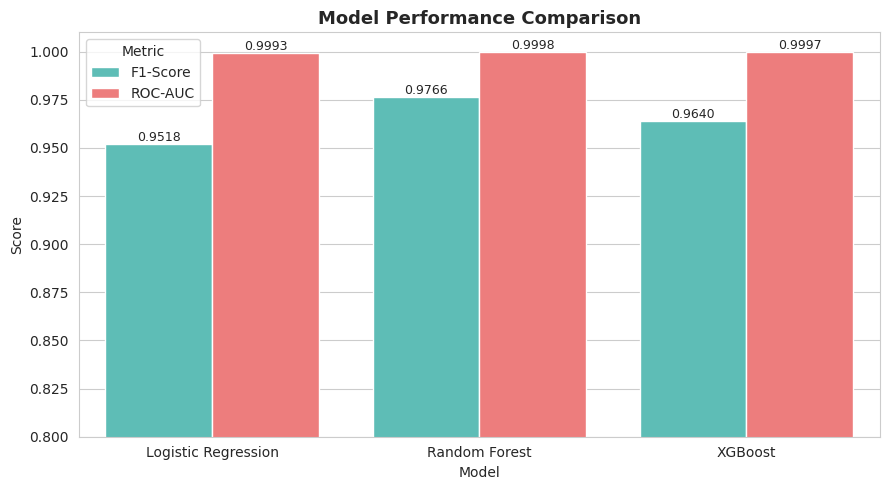

              Model  F1-Score  ROC-AUC
Logistic Regression  0.951810 0.999267
      Random Forest  0.976592 0.999762
            XGBoost  0.964002 0.999739


In [11]:
# Model comparison bar chart
metrics_df = pd.DataFrame(
    {name: {"F1-Score": res["f1"], "ROC-AUC": res["roc_auc"]} for name, res in results.items()}
).T.reset_index().rename(columns={"index": "Model"})

metrics_melted = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=metrics_melted, x="Model", y="Score", hue="Metric",
    palette=["#4ECDC4", "#FF6B6B"],
)
plt.ylim(0.80, 1.01)
plt.title("Model Performance Comparison", fontsize=13, fontweight="bold")
plt.ylabel("Score")
plt.legend(title="Metric")
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.4f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center", va="bottom", fontsize=9,
    )
plt.tight_layout()
plt.savefig("data/processed/fig_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(metrics_df.to_string(index=False))

## 6. Save Best Model

XGBoost is saved for SHAP explainability in notebook 03.

In [12]:
joblib.dump(results["XGBoost"]["model"], "models/xgb_model.joblib")
print("Saved → models/xgb_model.joblib")
print(f"\nFinal XGBoost results:")
print(f"  F1-Score : {results['XGBoost']['f1']:.4f}")
print(f"  ROC-AUC  : {results['XGBoost']['roc_auc']:.4f}")

Saved → models/xgb_model.joblib

Final XGBoost results:
  F1-Score : 0.9640
  ROC-AUC  : 0.9997
